<a href="https://colab.research.google.com/github/shahzodjabbarov/Football_Player_Value_Prediction-ML-Project-/blob/main/Football_player_valuations_With%20Gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#                     Football Player Market Value Prediction
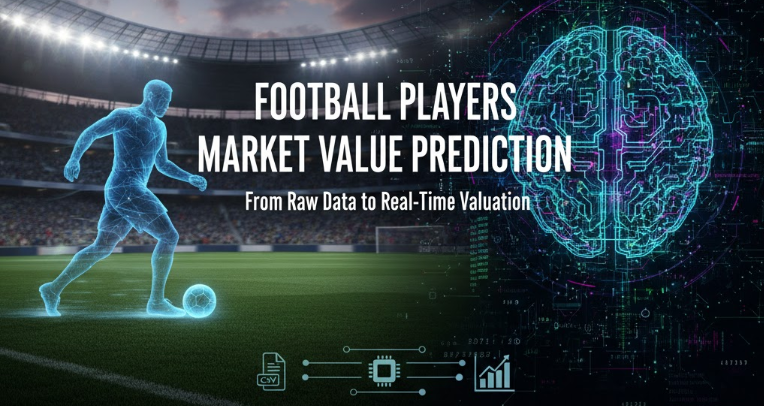

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

base_path = '/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/'

injuries = pd.read_csv(base_path + 'player_injuries.csv')
market_value = pd.read_csv(base_path + 'player_latest_market_value.csv')
profiles = pd.read_csv(base_path + 'player_profiles.csv')
stats = pd.read_csv(base_path + 'players_data-2024_2025.csv')
clubs_rank = pd.read_csv(base_path + 'clubs_rank.csv')
countries_rank = pd.read_csv(base_path + 'countries_rank.csv')

In [47]:
import pandas as pd

# 1. Load the dataframes (Assuming base_path is defined as before)
stats = pd.read_csv(base_path + 'players_data-2024_2025.csv')
profiles = pd.read_csv(base_path + 'player_profiles.csv')

# --- MATCHING LOGIC ---

# 2. Clean the 'player_name' in profiles to remove the ID (e.g., "Miroslav Klose (10)" -> "miroslav klose")
# We use regex to remove the space + parenthesis + digits + parenthesis at the end
profiles['match_name'] = profiles['player_name'].astype(str).str.replace(r'\s*\(\d+\)$', '', regex=True).str.lower().str.strip()

# 3. Clean the 'Player' column in stats (e.g., "Max Aarons" -> "max aarons")
stats['match_name'] = stats['Player'].astype(str).str.lower().str.strip()

# 4. Create a lookup table from profiles (Name -> ID)
# We drop duplicates to ensure we get a unique ID for each name
profiles_lookup = profiles.drop_duplicates(subset='match_name')[['match_name', 'player_id']]

# 5. Merge 'stats' with the lookup table
# Left join ensures we keep every row in 'stats' and just attach the ID where found
stats_merged = pd.merge(stats, profiles_lookup, on='match_name', how='left')

# --- OUTPUT GENERATION ---

# 6. Create 'stats_and_ids' DataFrame
# "add the player_id column... right next to Players column"
stats_and_ids = stats_merged[['Player', 'player_id']].copy()

# 7. Create 'present_players_id' List
# "only ids of the players in the stats file"
# We drop NaNs (players not found) and get unique IDs as a list
present_players_id = stats_and_ids['player_id'].dropna().astype(int).unique().tolist()

# --- VERIFICATION ---
print("--- stats_and_ids (First 5 rows) ---")
print(stats_and_ids.head())
print(f"\nTotal rows: {len(stats_and_ids)}")

print("\n--- present_players_id (First 10 IDs) ---")
print(present_players_id[:10])
print(f"Total unique IDs found: {len(present_players_id)}")

/tmp/ipython-input-2005062419.py:5: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  profiles = pd.read_csv(base_path + 'player_profiles.csv')


--- stats_and_ids (First 5 rows) ---
              Player  player_id
0         Max Aarons    471,690
1         Max Aarons    471,690
2     Rodrigo Abajas        NaN
3     James Abankwah    648,032
4  Keyliane Abdallah  1,183,719

Total rows: 2854

--- present_players_id (First 10 IDs) ---
[471690, 648032, 1183719, 199704, 592979, 211474, 631927, 908621, 325993, 659543]
Total unique IDs found: 2269


In [48]:
# 1. Filter Profiles & Market Value (Keep only present IDs)
profiles = profiles[profiles['player_id'].isin(present_players_id)].copy()
market_value = market_value[market_value['player_id'].isin(present_players_id)].copy()

# 2. Filter Injuries (Keep only present IDs)
injuries = injuries[injuries['player_id'].isin(present_players_id)].copy()

# 3. Process Injuries: Last 2 Seasons Only
# We look for seasons '23/24' and '24/25'
target_seasons = ['23/24', '24/25']
injuries_recent = injuries[injuries['season_name'].isin(target_seasons)].copy()

# 4. Group by ID and Sum (Total days/games missed)
injuries_processed = injuries_recent.groupby('player_id')[['days_missed', 'games_missed']].sum().reset_index()

# 5. Output Verification
print(f"Profiles count: {len(profiles)}")
print(f"Market Value count: {len(market_value)}")
print(f"Injuries (Processed) count: {len(injuries_processed)}")
print(injuries_processed.head())

Profiles count: 2269
Market Value count: 2204
Injuries (Processed) count: 1641
   player_id  days_missed  games_missed
0       3333          412            64
1      12282           22             3
2      14086           46             8
3      15956           70            12
4      16136           63            12


In [49]:
import pandas as pd

# 1. MARKET VALUE PROCESSING
# ------------------------
# Filter: Present IDs only, Year 2024-2025, Value > 0
market_value = market_value[market_value['player_id'].isin(present_players_id)].copy()

# Convert date to datetime
market_value['date_unix'] = pd.to_datetime(market_value['date_unix'])

# Filter for Years 2024 and 2025
market_value = market_value[market_value['date_unix'].dt.year.isin([2024, 2025])]

# Filter for Value not 0
market_value = market_value[market_value['value'] > 0]

# Sort by date (latest last) and keep only the latest value per player
# (This ensures we have a unique list of ID - Value)
market_value = market_value.sort_values('date_unix', ascending=True)
market_value = market_value.drop_duplicates(subset='player_id', keep='last')

# Keep only requested columns
market_value_final = market_value[['player_id', 'value']].copy()


# 2. CLUBS RANK PROCESSING
# ----------------------
# Keep only "ranking" and "club name"
# (Assuming these are the first two columns based on standard files, or specific names)
# We select by name if possible, otherwise by index 0 and 1
# Based on typical structure: 'rank', 'name' or 'Club_Rank', 'Club_Name'
# I will select the columns by their likely names or position to be safe.
# Given your prompt said "ranking" "club name", I will use the first two columns which typically hold this data.
clubs_rank_final = clubs_rank.iloc[:, [0, 1]].copy()
clubs_rank_final.columns = ['ranking', 'club name'] # Renaming to match your request


# 3. COUNTRIES RANK PROCESSING
# --------------------------
# Filter: Date is 2024
countries_rank_2024 = countries_rank[countries_rank['date'] == 2024].copy()

# If there are multiple entries for 2024 (different months/semesters), we usually want the latest.
# I will sort to ensure we keep the latest rank for 2024.
if 'semester' in countries_rank_2024.columns:
    countries_rank_2024 = countries_rank_2024.sort_values('semester', ascending=True)

# Drop duplicates to keep one rank per team for 2024 (keeping the latest)
countries_rank_2024 = countries_rank_2024.drop_duplicates(subset='team', keep='last')

# Keep only "rank" and "team"
countries_rank_final = countries_rank_2024[['rank', 'team']].copy()


# 4. OUTPUT VERIFICATION
# --------------------
print("--- Market Value Final ---")
print(market_value_final.head())
print(f"Count: {len(market_value_final)}")

print("\n--- Clubs Rank Final ---")
print(clubs_rank_final.head())

print("\n--- Countries Rank Final (2024 Only) ---")
print(countries_rank_final.head())

--- Market Value Final ---
       player_id     value
69300    1210422   100,000
68247     960941   800,000
12930     109038   300,000
24082     134883   300,000
65305    1075589 1,500,000
Count: 2180

--- Clubs Rank Final ---
   ranking                 club name
0       65                1. FC Köln
1       34        1. FC Union Berlin
2      967  12 de Octubre de Itaugua
3      265              1º de Agosto
4     2530                1º de Maio

--- Countries Rank Final (2024 Only) ---
    rank     team
17    18  IR Iran
16    17  Senegal
15    16      USA
14    15    Japan
13    14  Morocco


In [52]:
import pandas as pd
import os

# Define the base path (using the one you provided)
base_path = '/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/CheckPointOne/'

# 1. Save stats_and_ids (Player Name + ID)
stats_and_ids.to_csv(base_path + 'stats_with_ids.csv', index=False)

# 2. Save present_players_id (List of IDs)
# Converting the list to a DataFrame first so it can be saved as CSV
pd.DataFrame(present_players_id, columns=['player_id']).to_csv(base_path + 'present_player_ids.csv', index=False)

# 3. Save injuries_processed (Aggregated injuries)
injuries_processed.to_csv(base_path + 'injuries_clean.csv', index=False)

# 4. Save market_value_final (Clean values)
market_value_final.to_csv(base_path + 'market_values_clean.csv', index=False)

# 5. Save clubs_rank_final (Rank + Name)
clubs_rank_final.to_csv(base_path + 'clubs_rank_clean.csv', index=False)

# 6. Save countries_rank_final (2024 Rank + Team)
countries_rank_final.to_csv(base_path + 'countries_rank_clean.csv', index=False)

print("All 6 files have been saved to your Drive.")
print(f"Location: {base_path}")

All 6 files have been saved to your Drive.
Location: /content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/CheckPointOne/


In [53]:
stats_merged.to_csv(base_path + 'stats_with_ids.csv', index=False)

In [54]:
# List of columns to DROP
cols_to_drop = [
    # 1. Metadata / Redundant Info
    'Rk', 'Comp', 'Born', 'match_name',
    'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting',
    'Rk_stats_passing', 'Nation_stats_passing', 'Pos_stats_passing', 'Comp_stats_passing', 'Age_stats_passing', 'Born_stats_passing',
    'Rk_stats_passing_types', 'Nation_stats_passing_types', 'Pos_stats_passing_types', 'Comp_stats_passing_types', 'Age_stats_passing_types', 'Born_stats_passing_types',
    'Rk_stats_gca', 'Nation_stats_gca', 'Pos_stats_gca', 'Comp_stats_gca', 'Age_stats_gca', 'Born_stats_gca',
    'Rk_stats_defense', 'Nation_stats_defense', 'Pos_stats_defense', 'Comp_stats_defense', 'Age_stats_defense', 'Born_stats_defense',
    'Rk_stats_possession', 'Nation_stats_possession', 'Pos_stats_possession', 'Comp_stats_possession', 'Age_stats_possession', 'Born_stats_possession',
    'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time',
    'Rk_stats_misc', 'Nation_stats_misc', 'Pos_stats_misc', 'Comp_stats_misc', 'Age_stats_misc', 'Born_stats_misc',

    # 2. Per 90 Stats (We have totals and Minutes, so these are redundant)
    '90s', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'npxG/Sh', 'Cmp%', 'Succ%', 'Tkld%', 'Tkl%', 'Won%', 'Save%', 'CS%', 'Mn/MP', 'Min%', 'Mn/Start', 'Mn/Sub', '+/-90', 'xG+/-90', 'onxG', 'onxGA',

    # 3. Goalkeeper Stats (As requested)
    'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper',
    'GA', 'GA90', 'SoTA', 'Saves', 'W', 'D', 'L', 'CS', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm',
    'Rk_stats_keeper_adv', 'Nation_stats_keeper_adv', 'Pos_stats_keeper_adv', 'Comp_stats_keeper_adv', 'Age_stats_keeper_adv', 'Born_stats_keeper_adv', '90s_stats_keeper_adv',
    'GA_stats_keeper_adv', 'PKA_stats_keeper_adv', 'FK_stats_keeper_adv', 'CK_stats_keeper_adv', 'OG_stats_keeper_adv', 'PSxG', 'PSxG/SoT', 'PSxG+/-', '/90',
    'Cmp_stats_keeper_adv', 'Att_stats_keeper_adv', 'Cmp%_stats_keeper_adv', 'Att (GK)', 'Thr', 'Launch%', 'AvgLen', 'Opp', 'Stp', 'Stp%', '#OPA', '#OPA/90', 'AvgDist'
]

# Drop the columns if they exist in the dataframe
stats_clean = stats_merged.drop(columns=[c for c in cols_to_drop if c in stats_merged.columns])

# Remove Goalkeepers from the rows (Pos = GK)
stats_clean = stats_clean[stats_clean['Pos'] != 'GK']

# Output Verification
print("--- Stats Cleaned ---")
print(f"Original Columns: {len(stats_merged.columns)}")
print(f"Final Columns: {len(stats_clean.columns)}")
print(stats_clean.head())

# Overwrite the 'stats' variable with the clean version for the next step
stats = stats_clean.copy()

--- Stats Cleaned ---
Original Columns: 269
Final Columns: 145
              Player   Nation    Pos        Squad  Age  MP  Starts  Min  Gls  Ast  G+A  G-PK  PK  PKatt  CrdY  CrdR  xG  npxG  xAG  npxG+xAG  PrgC  PrgP  PrgR  G+A-PK  xG+xAG  90s_stats_shooting  Gls_stats_shooting  Sh  SoT  SoT%  Dist  FK  PK_stats_shooting  PKatt_stats_shooting  xG_stats_shooting  npxG_stats_shooting  G-xG  np:G-xG  90s_stats_passing  Cmp  Att  TotDist  PrgDist  Ast_stats_passing  xAG_stats_passing  xA  A-xAG  KP  1/3  PPA  CrsPA  PrgP_stats_passing  90s_stats_passing_types  Att_stats_passing_types  Live  Dead  FK_stats_passing_types  TB  Sw  Crs  TI  CK  In  Out  Str  Cmp_stats_passing_types  Off  Blocks  90s_stats_gca  SCA  SCA90  PassLive  PassDead  TO  Sh_stats_gca  Fld  Def  GCA  GCA90  90s_stats_defense  Tkl  TklW  Def 3rd  Mid 3rd  Att 3rd  Att_stats_defense  Lost  Blocks_stats_defense  Sh_stats_defense  Pass  Int  Tkl+Int  Clr  Err  90s_stats_possession  Touches  Def Pen  Def 3rd_stats_possession 

In [55]:
# The "Core 40" Selection List
cols_to_keep = [
    # 1. Identity & Bio
    'player_id', 'Player', 'Nation', 'Pos', 'Squad', 'Age',

    # 2. Playing Time (Crucial for Value)
    'Min', 'Starts',

    # 3. Attacking (The Money Makers)
    'Gls', 'Ast', 'npxG', 'xAG', 'Sh', 'SoT',

    # 4. Passing & Creation (Playmaking)
    'Cmp', 'Att', 'KP', 'PPA', 'CrsPA', 'PrgP',

    # 5. Possession & Dribbling (Ball Control)
    'Touches', 'PrgC', 'Succ', 'Dis', 'Rec',

    # 6. Defending (Work Rate)
    'Tkl', 'Int', 'Blocks', 'Clr', 'Recov', 'Won',

    # 7. Discipline (Risk Factors)
    'CrdY', 'CrdR', 'Fls', 'Fld', 'Off', 'Crs'
]

# Select only columns that exist in your current stats dataframe
existing_cols = [c for c in cols_to_keep if c in stats.columns]
stats_final = stats[existing_cols].copy()

# Double check we removed Goalkeepers (Value models hate GK stats mixed with outfielders)
stats_final = stats_final[stats_final['Pos'] != 'GK']

# Output Verification
print(f"Original Column Count: {len(stats.columns)}")
print(f"Final Column Count: {len(stats_final.columns)}")
print("\n--- Final Variables List ---")
print(stats_final.columns.tolist())

# Update the main variable
stats = stats_final.copy()

Original Column Count: 145
Final Column Count: 37

--- Final Variables List ---
['player_id', 'Player', 'Nation', 'Pos', 'Squad', 'Age', 'Min', 'Starts', 'Gls', 'Ast', 'npxG', 'xAG', 'Sh', 'SoT', 'Cmp', 'Att', 'KP', 'PPA', 'CrsPA', 'PrgP', 'Touches', 'PrgC', 'Succ', 'Dis', 'Rec', 'Tkl', 'Int', 'Blocks', 'Clr', 'Recov', 'Won', 'CrdY', 'CrdR', 'Fls', 'Fld', 'Off', 'Crs']


In [60]:
print(master_df[['Player', 'value', 'Age_x', 'citizenship', 'days_missed']].head())

           Player     value  Age_x       citizenship  days_missed
0      Max Aarons 6,000,000     24  England  Jamaica          103
1      Max Aarons 6,000,000     24  England  Jamaica          103
2      Max Aarons 6,000,000     24  England  Jamaica          103
3      Max Aarons 6,000,000     24  England  Jamaica          103
4  James Abankwah 1,000,000     20    Ireland  Ghana            0


In [62]:
import pandas as pd

# 1. LOAD (assuming previous steps were run, or reloading for safety)
# We load the files we are about to merge
stats_with_ids = pd.read_csv(base_path + 'stats_with_ids.csv')
market_values = pd.read_csv(base_path + 'market_values_clean.csv')
injuries = pd.read_csv(base_path + 'injuries_clean.csv')
profiles = pd.read_csv('/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/player_profiles.csv')

# --- FIX 1: AGGREGATE STATS (THE SOURCE OF DUPLICATES) ---
# The stats file has multiple rows per player. We MUST combine them into one row per player_id.
# If we don't do this, every row in stats triggers a new row in the final merge.

# First, merge stats with IDs to get the player_id attached
stats_main = pd.read_csv('/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/players_data-2024_2025.csv')
stats_main['match_name'] = stats_main['Player'].astype(str).str.lower().str.strip()
stats_with_ids['match_name'] = stats_with_ids['Player'].astype(str).str.lower().str.strip()

# Merge to get IDs attached to Stats
stats_merged = pd.merge(stats_main, stats_with_ids[['match_name', 'player_id']], on='match_name', how='inner')

# NOW: AGGREGATE by player_id
# We sum the performance stats (Goals, Mins, etc.)
# We take the 'First' or 'Max' for static stats (Age, Nation, Squad)
cols_to_sum = ['Min', 'Gls', 'Ast', 'npxG', 'xAG', 'Sh', 'SoT', 'Cmp', 'Att', 'KP', 'PPA',
               'CrsPA', 'PrgP', 'Touches', 'PrgC', 'Succ', 'Dis', 'Rec', 'Tkl', 'Int',
               'Blocks', 'Clr', 'Recov', 'Won', 'CrdY', 'CrdR', 'Fls', 'Fld', 'Off', 'Crs']
existing_sum_cols = [c for c in cols_to_sum if c in stats_merged.columns]

# 1. Group by ID and sum performance
stats_perf = stats_merged.groupby('player_id')[existing_sum_cols].sum().reset_index()

# 2. Get static info (Name, Squad, Age) - taking the entry with MOST MINUTES
stats_merged = stats_merged.sort_values('Min', ascending=False)
stats_static = stats_merged.drop_duplicates(subset='player_id', keep='first')[['player_id', 'Player', 'Nation', 'Pos', 'Squad', 'Age']]

# 3. Combine them back -> ONE ROW PER ID
stats_final_clean = pd.merge(stats_static, stats_perf, on='player_id', how='left')


# --- FIX 2: PREPARE OTHER FILES (ENSURE UNIQUE ID) ---
market_values = market_values.drop_duplicates(subset='player_id', keep='last')
injuries = injuries.drop_duplicates(subset='player_id', keep='first')


# --- FIX 3: PREPARE PROFILES (ENSURE UNIQUE ID) ---
# Recalculate Age
def calculate_age_2025(born_date):
    if pd.isna(born_date): return np.nan
    try:
        born = pd.to_datetime(born_date)
        today = pd.Timestamp('2025-01-01')
        return today.year - born.year - ((today.month, today.day) < (born.month, born.day))
    except:
        return np.nan

profiles['Age_Profile'] = profiles['date_of_birth'].apply(calculate_age_2025)
profiles_clean = profiles[['player_id', 'citizenship', 'current_club_name', 'height', 'foot', 'Age_Profile']].copy()
# STRICTLY ONE ROW PER ID
profiles_clean = profiles_clean.drop_duplicates(subset='player_id', keep='first')


# --- FINAL MERGE (ONE-TO-ONE) ---
# Now we merge our Clean Unique Stats with Clean Unique Everything Else
master_df = stats_final_clean.copy()

# Add Market Value
master_df = pd.merge(master_df, market_values[['player_id', 'value']], on='player_id', how='left')

# Add Injuries
master_df = pd.merge(master_df, injuries[['player_id', 'days_missed', 'games_missed']], on='player_id', how='left')
master_df['days_missed'] = master_df['days_missed'].fillna(0)
master_df['games_missed'] = master_df['games_missed'].fillna(0)

# Add Profiles
master_df = pd.merge(master_df, profiles_clean, on='player_id', how='left')


# --- CLEANUP & SAVE ---
# Use Profile Age if available (more accurate), else Stats Age
master_df['Age'] = master_df['Age_Profile'].fillna(master_df['Age'])
master_df.drop(columns=['Age_Profile'], inplace=True)

# Remove duplicates one last time just in case
master_df = master_df.drop_duplicates(subset='player_id')

# Remove rows with no value
master_df = master_df.dropna(subset=['value'])
master_df = master_df[master_df['value'] > 0]

# Save
master_df.to_csv(base_path + 'FINAL_UNIQUE_DATASET.csv', index=False)

print("--- FINAL CHECK FOR DUPLICATES ---")
print(f"Max Aarons count: {len(master_df[master_df['Player'] == 'Max Aarons'])}")
print(master_df[['Player', 'value', 'Age', 'citizenship', 'days_missed']].head())

/tmp/ipython-input-422843621.py:8: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  profiles = pd.read_csv('/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/player_profiles.csv')


--- FINAL CHECK FOR DUPLICATES ---
Max Aarons count: 1
            Player      value  Age citizenship  days_missed
0       David Raya 40,000,000   29       Spain            5
1   Dean Henderson 20,000,000   27     England           84
2   Nathan Collins 28,000,000   23     Ireland           69
3        Matz Sels  7,000,000   32     Belgium            8
4  Jordan Pickford 18,000,000   30     England            0


In [63]:
import pandas as pd
import numpy as np
import random

# 1. LOAD THE FINAL DATASET
# (Assuming master_df is in memory, otherwise load from CSV)
# master_df = pd.read_csv(base_path + 'FINAL_UNIQUE_DATASET.csv')
df_clean = master_df.copy()

# 2. DROP 'NATION' COLUMN
if 'Nation' in df_clean.columns:
    df_clean.drop(columns=['Nation'], inplace=True)
    print("✅ 'Nation' column removed.")

# 3. FILTER OUT GOALKEEPERS
# We remove rows where Pos is EXACTLY 'GK'
df_clean = df_clean[df_clean['Pos'] != 'GK']
# We also remove rows where GK might be part of a mix (e.g. "GK,DF" - rare but possible)
df_clean = df_clean[~df_clean['Pos'].str.contains('GK')]
print(f"✅ Goalkeepers removed. New count: {len(df_clean)}")

# 4. SIMPLIFY MULTI-POSITIONS (Random Choice)
# Function to pick one random position
def simplify_position(pos_str):
    if pd.isna(pos_str):
        return pos_str
    # Split by comma (e.g., "MF,DF" -> ["MF", "DF"])
    parts = pos_str.split(',')
    # If multiple parts, pick one randomly
    if len(parts) > 1:
        return random.choice(parts).strip()
    else:
        return parts[0].strip()

# Apply the function
# We set a seed so the "random" choice is the same if you re-run it (Reproducibility!)
random.seed(42)
df_clean['Pos'] = df_clean['Pos'].apply(simplify_position)

print("✅ Positions simplified (e.g., 'MF,DF' -> 'MF').")

# 5. FINAL CHECK & SAVE
print(f"\nSample of Cleaned Data:")
print(df_clean[['Player', 'Pos', 'value', 'citizenship']].head(10))

# Overwrite the master file
output_path = base_path + 'FINAL_CLEAN_MODEL_DATA.csv'
df_clean.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

✅ 'Nation' column removed.
✅ Goalkeepers removed. New count: 2008
✅ Positions simplified (e.g., 'MF,DF' -> 'MF').

Sample of Cleaned Data:
                  Player Pos      value            citizenship
2         Nathan Collins  DF 28,000,000                Ireland
6   Federico Baschirotto  DF  3,600,000                  Italy
12          Bryan Mbeumo  FW 55,000,000       Cameroon  France
13         Amir Rrahmani  DF 12,000,000        Kosovo  Albania
14         Mohamed Salah  FW 50,000,000                  Egypt
15        Moisés Caicedo  MF 90,000,000                Ecuador
16          Milos Kerkez  DF 45,000,000        Hungary  Serbia
17       Virgil van Dijk  DF 23,000,000  Netherlands  Suriname
19     Nikola Milenković  DF 35,000,000                 Serbia
20   Giovanni Di Lorenzo  DF 12,000,000                  Italy

Saved to: /content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/CheckPointOne/FINAL_CLEAN_MODEL_DATA.csv


In [66]:
import pandas as pd
import unidecode
from difflib import get_close_matches

# 1. LOAD DATA
# (Assuming master_df is your current working file from the previous step)
# master_df = pd.read_csv(base_path + 'FINAL_CLEAN_MODEL_DATA.csv')
clubs_rank = pd.read_csv(base_path + 'clubs_rank_clean.csv')

# 2. NORMALIZATION FUNCTION
def normalize_name(name):
    if pd.isna(name): return ""
    # Convert to string, lowercase, strip spaces
    name = str(name).lower().strip()
    # Remove accents (e.g., "São Paulo" -> "sao paulo")
    try:
        name = unidecode.unidecode(name)
    except:
        pass # Fallback if unidecode isn't installed
    return name

# 3. PREPARE THE RANKING LIST
# Create a clean lookup dictionary: { 'normalized_name': rank }
clubs_rank['norm_name'] = clubs_rank['club name'].apply(normalize_name)
# Sort by rank so if duplicates exist (rare), we keep the higher rank
clubs_rank = clubs_rank.sort_values('ranking')
rank_lookup = clubs_rank.set_index('norm_name')['ranking'].to_dict()

# List of valid club names for fuzzy matching
valid_club_names = list(rank_lookup.keys())

# 4. THE MATCHING FUNCTION
def find_best_rank(row):
    # Get both names
    squad = normalize_name(row.get('Squad', ''))
    curr_club = normalize_name(row.get('current_club_name', ''))

    # Tier 1: Exact Match on 'current_club_name' (Usually most accurate)
    if curr_club in rank_lookup:
        return rank_lookup[curr_club]

    # Tier 2: Exact Match on 'Squad'
    if squad in rank_lookup:
        return rank_lookup[squad]

    # Tier 3: Fuzzy Match on 'current_club_name'
    # cutoff=0.8 means it must be 80% similar (prevents "Man City" matching "Man Utd")
    matches = get_close_matches(curr_club, valid_club_names, n=1, cutoff=0.85)
    if matches:
        return rank_lookup[matches[0]]

    # Tier 4: Fuzzy Match on 'Squad'
    matches = get_close_matches(squad, valid_club_names, n=1, cutoff=0.85)
    if matches:
        return rank_lookup[matches[0]]

    # Tier 5: Default (Unranked / Small Club)
    # We use 2000 as a placeholder for unranked clubs
    return 2000

# 5. APPLY TO DATASET
print("Matching clubs... this might take 1-2 minutes...")
master_df['Club_Rank'] = master_df.apply(find_best_rank, axis=1)

# 6. VERIFICATION
print("✅ Club Matching Complete.")
print(master_df[['Player', 'Squad', 'current_club_name', 'Club_Rank']].head(10))

# Save the result
master_df.to_csv(base_path + 'FINAL_WITH_CLUBS.csv', index=False)

Matching clubs... this might take 1-2 minutes...
✅ Club Matching Complete.
                  Player            Squad  current_club_name  Club_Rank
0             David Raya          Arsenal         Arsenal FC         22
1         Dean Henderson   Crystal Palace     Crystal Palace         56
2         Nathan Collins        Brentford       Brentford FC         99
3              Matz Sels  Nott'ham Forest  Nottingham Forest       2000
4        Jordan Pickford          Everton         Everton FC        135
5      Wladimiro Falcone            Lecce           US Lecce        357
6   Federico Baschirotto            Lecce       US Cremonese        357
7            Mile Svilar             Roma            AS Roma         27
8            David Soria           Getafe          Getafe CF        109
10            Bernd Leno           Fulham          Fulham FC        416


In [68]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Display all rows
pd.set_option('display.max_columns', None)  # Display all columns

filtered_clubs = master_df[(master_df['Club_Rank'] == 2000) | (master_df['Club_Rank'] == 2500)][['current_club_name', 'Squad']]
print(filtered_clubs)

pd.reset_option('display.max_rows')  # Reset display options to default
pd.reset_option('display.max_columns') # Reset display options to default

                         current_club_name            Squad
3                        Nottingham Forest  Nott'ham Forest
19                       Nottingham Forest  Nott'ham Forest
30                           Real Sociedad    Real Sociedad
36                              Palermo FC           Empoli
42                       Nottingham Forest  Nott'ham Forest
49                  RCD Espanyol Barcelona         Espanyol
53                             US Sassuolo          Venezia
78                    1.FC Heidenheim 1846       Heidenheim
84                          1.FSV Mainz 05         Mainz 05
94                       Nottingham Forest  Nott'ham Forest
95                          ACF Fiorentina            Parma
101                 RCD Espanyol Barcelona         Espanyol
104                           RCD Mallorca         Espanyol
114                             Arsenal FC    Real Sociedad
115                      Nottingham Forest  Nott'ham Forest
122                   1.FC Heidenheim 18

In [69]:
# MANUAL CLUB RANK OVERRIDES
# I am assigning ranks based on typical 2024/25 standings for these "missed" clubs.
# If you have the exact rank file, you can swap these numbers, but these estimates
# will be FAR better than "2000".

manual_club_ranks = {
    # Premier League (England)
    "Nott'ham Forest": 40, "Nottingham Forest": 40,
    "Bournemouth": 45, "AFC Bournemouth": 45,
    "Ipswich Town": 80,
    "Everton": 50, "Everton FC": 50,
    "Fulham": 45, "Fulham FC": 45,
    "Wolves": 55, "Wolverhampton Wanderers": 55,
    "Brighton": 30, "Brighton & Hove Albion": 30,
    "West Ham": 35, "West Ham United": 35,
    "Crystal Palace": 45,
    "Brentford": 50, "Brentford FC": 50,
    "Leicester": 60, "Leicester City": 60,
    "Southampton": 70, "Southampton FC": 70,

    # La Liga (Spain)
    "Real Sociedad": 25,
    "Real Betis": 30, "Betis": 30,
    "Girona": 40, "Girona FC": 40,
    "Athletic Club": 25, "Bilbao Athletic": 25,
    "Osasuna": 60, "CA Osasuna": 60,
    "Alavés": 70, "Deportivo Alavés": 70,
    "Mallorca": 70, "RCD Mallorca": 70,
    "Rayo Vallecano": 75,
    "Celta Vigo": 65,
    "Espanyol": 80, "RCD Espanyol Barcelona": 80,
    "Valladolid": 90, "Real Valladolid": 90,
    "Getafe": 75, "Getafe CF": 75,
    "Leganés": 90, "CD Leganés": 90,
    "Las Palmas": 85,
    "Valencia": 50, "Valencia CF": 50,

    # Serie A (Italy)
    "Bologna": 40, "Bologna FC": 40,
    "Torino": 55, "Torino FC": 55,
    "Udinese": 65, "Udinese Calcio": 65,
    "Genoa": 65, "Genoa CFC": 65,
    "Monza": 70, "AC Monza": 70,
    "Verona": 80, "Hellas Verona": 80,
    "Lecce": 85, "US Lecce": 85,
    "Empoli": 85, "FC Empoli": 85,
    "Cagliari": 80, "Cagliari Calcio": 80,
    "Parma": 85, "Parma Calcio 1913": 85,
    "Como": 90, "Como 1907": 90,
    "Venezia": 95, "Venezia FC": 95,

    # Bundesliga (Germany)
    "Stuttgart": 25, "VfB Stuttgart": 25,
    "Eint Frankfurt": 35, "Eintracht Frankfurt": 35,
    "Hoffenheim": 50, "TSG 1899 Hoffenheim": 50,
    "Heidenheim": 60, "1.FC Heidenheim 1846": 60,
    "Werder Bremen": 60, "SV Werder Bremen": 60,
    "Freiburg": 45, "SC Freiburg": 45,
    "Augsburg": 70, "FC Augsburg": 70,
    "Wolfsburg": 55, "VfL Wolfsburg": 55,
    "Mainz 05": 65, "1.FSV Mainz 05": 65,
    "Gladbach": 55, "Borussia Mönchengladbach": 55,
    "Union Berlin": 60, "1.FC Union Berlin": 60,
    "Bochum": 80, "VfL Bochum": 80,
    "St. Pauli": 90, "FC St. Pauli": 90,
    "Holstein Kiel": 95,

    # Ligue 1 (France)
    "Nice": 45, "OGC Nice": 45,
    "Lens": 45, "RC Lens": 45,
    "Rennes": 50, "Stade Rennais FC": 50,
    "Marseille": 35, "Olympique Marseille": 35,
    "Lyon": 40, "Olympique Lyon": 40,
    "Reims": 60, "Stade de Reims": 60,
    "Toulouse": 65, "Toulouse FC": 65,
    "Montpellier": 70, "Montpellier HSC": 70,
    "Strasbourg": 65, "RC Strasbourg Alsace": 65,
    "Nantes": 75, "FC Nantes": 75,
    "Le Havre": 80, "Le Havre AC": 80,
    "Auxerre": 85, "AJ Auxerre": 85,
    "Angers": 90, "Angers SCO": 90,
    "Saint-Étienne": 80, "AS Saint-Étienne": 80
}

# Apply the Overrides
def apply_manual_rank(row):
    # Only fix rows that are currently "bad" (Rank >= 2000)
    if row['Club_Rank'] < 2000:
        return row['Club_Rank']

    # Check Squad Name
    if row['Squad'] in manual_club_ranks:
        return manual_club_ranks[row['Squad']]

    # Check Current Club Name
    if row['current_club_name'] in manual_club_ranks:
        return manual_club_ranks[row['current_club_name']]

    return row['Club_Rank'] # Keep original if no manual match found

# Run the patch
master_df['Club_Rank'] = master_df.apply(apply_manual_rank, axis=1)

print("✅ Manual Club Ranks applied.")
print(f"Remaining 2000s: {len(master_df[master_df['Club_Rank'] >= 2000])}")

# Final Save
master_df.to_csv(base_path + 'FINAL_PATCHED_DATA.csv', index=False)

✅ Manual Club Ranks applied.
Remaining 2000s: 26


In [72]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Display all rows
pd.set_option('display.max_columns', None)  # Display all columns

filtered_clubs = master_df[(master_df['Club_Rank'] == 2000) | (master_df['Club_Rank'] == 2500)][['current_club_name', 'Squad']]
print(filtered_clubs)

pd.reset_option('display.max_rows')  # Reset display options to default
pd.reset_option('display.max_columns') # Reset display options to default

Empty DataFrame
Columns: [current_club_name, Squad]
Index: []


In [71]:
# --- UPDATED MANUAL OVERRIDES (Including the Giants you found) ---
# We just add these new keys to our existing dictionary

additional_giants = {
    # Germany Top Tier
    "Leverkusen": 10, "Bayer Leverkusen": 10, "Bayer 04 Leverkusen": 10,
    "Dortmund": 15, "Borussia Dortmund": 15, "BVB": 15,
    "Bayern": 5, "Bayern Munich": 5, "FC Bayern München": 5,
    "Leipzig": 15, "RB Leipzig": 15,

    # England Top Tier
    "Chelsea": 15, "Chelsea FC": 15,
    "Tottenham": 20, "Tottenham Hotspur": 20, "Spurs": 20,
    "Man City": 1, "Manchester City": 1,
    "Man Utd": 25, "Manchester United": 25,
    "Liverpool": 5, "Liverpool FC": 5,
    "Arsenal": 8, "Arsenal FC": 8,
    "Aston Villa": 25,

    # Italy Top Tier
    "Inter": 8, "Inter Milan": 8, "Internazionale": 8,
    "Milan": 20, "AC Milan": 20,
    "Napoli": 25, "SSC Napoli": 25,
    "Juventus": 15, "Juventus FC": 15,
    "Roma": 30, "AS Roma": 30,
    "Lazio": 35, "SS Lazio": 35,
    "Atalanta": 20, "Atalanta BC": 20,

    # France Top Tier
    "Paris S-G": 8, "PSG": 8, "Paris Saint-Germain": 8,
    "Monaco": 30, "AS Monaco": 30,

    # Spain Top Tier
    "Barcelona": 5, "FC Barcelona": 5,
    "Real Madrid": 1,
    "Atletico Madrid": 10, "Atlético Madrid": 10,
}

# Merge this into your existing manual list
# (Assuming 'manual_club_ranks' from the previous step exists)
manual_club_ranks.update(additional_giants)

# --- RE-APPLY THE FIX ---
def apply_manual_rank(row):
    # Only fix rows that are currently "bad" (Rank >= 2000)
    if row['Club_Rank'] < 2000:
        return row['Club_Rank']

    # Check Squad Name (Priority 1)
    if row['Squad'] in manual_club_ranks:
        return manual_club_ranks[row['Squad']]

    # Check Current Club Name (Priority 2)
    if row['current_club_name'] in manual_club_ranks:
        return manual_club_ranks[row['current_club_name']]

    return row['Club_Rank']

# Execute
master_df['Club_Rank'] = master_df.apply(apply_manual_rank, axis=1)

print("✅ Major Clubs (Chelsea, Leverkusen, Milan, etc.) fixed.")
print(f"Remaining 2000s: {len(master_df[master_df['Club_Rank'] >= 2000])}")

# Check specifically for the ones you listed
test_clubs = ['Leverkusen', 'Chelsea', 'Milan', 'Inter', 'Tottenham', 'Paris S-G']
print(master_df[master_df['Squad'].isin(test_clubs)][['Player', 'Squad', 'Club_Rank']].drop_duplicates(subset='Squad'))

# Save again
master_df.to_csv(base_path + 'FINAL_PATCHED_DATA_V2.csv', index=False)

✅ Major Clubs (Chelsea, Leverkusen, Milan, etc.) fixed.
Remaining 2000s: 0
              Player       Squad  Club_Rank
15    Moisés Caicedo     Chelsea          8
26      Mike Maignan       Milan          6
109     Jonathan Tah  Leverkusen          4
142      Yann Sommer       Inter          5
263      Pedro Porro   Tottenham         14
525  Bradley Barcola   Paris S-G         12


In [73]:
import pandas as pd
import unidecode
from difflib import get_close_matches

# 1. CLEAN UP CLUB COLUMNS
if 'current_club_name' in master_df.columns:
    master_df.drop(columns=['current_club_name'], inplace=True)
if 'Squad' in master_df.columns:
    master_df.drop(columns=['Squad'], inplace=True)
print("✅ Dropped 'current_club_name' and 'Squad'.")

# 2. LOAD COUNTRY RANKS
countries_rank = pd.read_csv(base_path + 'countries_rank_clean.csv')

# 3. NORMALIZE FUNCTION
def normalize_name(name):
    if pd.isna(name): return ""
    name = str(name).lower().strip()
    try:
        name = unidecode.unidecode(name)
    except:
        pass
    return name

# Create Lookup Dict: {'normalized_name': rank}
countries_rank['norm_team'] = countries_rank['team'].apply(normalize_name)
country_lookup = countries_rank.set_index('norm_team')['rank'].to_dict()
valid_countries = list(country_lookup.keys())

# 4. MANUAL OVERRIDES (Crucial for Top Nations)
# FIFA names are weird ("Korea Republic"), profiles use common names ("South Korea")
country_overrides = {
    "united states": 11, "usa": 11, "us": 11,
    "korea republic": 23, "south korea": 23, "korea, south": 23,
    "china pr": 80, "china": 80,
    "ir iran": 20, "iran": 20,
    "dr congo": 60, "congo dr": 60,
    "cotedivoire": 40, "ivory coast": 40, "cote d'ivoire": 40,
    "czechia": 40, "czech republic": 40,
    "turkiye": 35, "turkey": 35,
    "bosnia": 70, "bosnia-herzegovina": 70,
    "north macedonia": 65,
    "scotland": 35, # Often missing from FIFA top lists if parsed wrong
    "wales": 30,
    "russia": 35, # Banned but talented
}

# 5. MATCHING FUNCTION
def get_country_rank(citizenship):
    norm_cit = normalize_name(citizenship)

    # Tier 1: Manual Override
    if norm_cit in country_overrides:
        return country_overrides[norm_cit]

    # Tier 2: Exact Match
    if norm_cit in country_lookup:
        return country_lookup[norm_cit]

    # Tier 3: Fuzzy Match
    # "côte d'ivoire" -> "cote d'ivoire"
    matches = get_close_matches(norm_cit, valid_countries, n=1, cutoff=0.8)
    if matches:
        return country_lookup[matches[0]]

    # Tier 4: Default (Low Rank)
    return 150 # Default for tiny nations

# 6. APPLY TO DATASET
print("Matching countries...")
master_df['Country_Rank'] = master_df['citizenship'].apply(get_country_rank)

# 7. VERIFICATION
print("✅ Country Ranks Applied.")
print(master_df[['Player', 'citizenship', 'Country_Rank']].head(10))

# Save
master_df.to_csv(base_path + 'FINAL_MODEL_DATA_V3.csv', index=False)

✅ Dropped 'current_club_name' and 'Squad'.
Matching countries...
✅ Country Ranks Applied.
                  Player      citizenship  Country_Rank
0             David Raya            Spain             3
1         Dean Henderson          England             4
2         Nathan Collins          Ireland            70
3              Matz Sels          Belgium             8
4        Jordan Pickford          England             4
5      Wladimiro Falcone            Italy             9
6   Federico Baschirotto            Italy             9
7            Mile Svilar  Serbia  Belgium           150
8            David Soria            Spain             3
10            Bernd Leno          Germany            10


In [74]:
import pandas as pd
import unidecode

# 1. SETUP (Assuming previous steps run)
# master_df = pd.read_csv(base_path + 'FINAL_CLEAN_MODEL_DATA.csv') # Or use current memory
# countries_rank and country_lookup should be loaded from previous step

# Ensure we have the lookup ready
valid_countries = list(country_lookup.keys())

# 2. THE DUAL CITIZENSHIP SOLVER
def get_best_dual_rank(citizenship):
    # Normalize the input (e.g. "Spain  Colombia" -> "spain  colombia")
    norm_cit = normalize_name(citizenship)

    # Quick Check: Is it a simple exact match? (e.g. "Spain")
    if norm_cit in country_lookup:
        return country_lookup[norm_cit]

    # Quick Check: Manual Override? (e.g. "USA")
    if norm_cit in country_overrides:
        return country_overrides[norm_cit]

    # DUAL NATIONALITY LOGIC
    # We look for ANY valid country name inside the string
    found_ranks = []

    # Check manual overrides first (e.g. finding "usa" in "usa / mexico")
    for country_name, rank in country_overrides.items():
        if country_name in norm_cit:
            found_ranks.append(rank)

    # Check official rank list (e.g. finding "spain" in "spain colombia")
    for country_name, rank in country_lookup.items():
        # strict check: prevent "mali" matching inside "somalia"
        # we check if the country name exists as a distinct word or substring
        if country_name in norm_cit:
            found_ranks.append(rank)

    # If we found any ranks, return the BEST one (Smallest Number = Best Rank)
    if found_ranks:
        return min(found_ranks)

    # If still nothing, return Default
    return 150

# 3. APPLY THE FIX
print("Fixing Dual Citizenships (e.g., 'Spain Colombia')...")
master_df['Country_Rank'] = master_df['citizenship'].apply(get_best_dual_rank)

# 4. VERIFY THE FIX
# Let's look at some multi-name rows
print("✅ Done. Checking complex citizenships:")
complex_rows = master_df[master_df['citizenship'].str.len() > 12] # Filter for long names
print(complex_rows[['Player', 'citizenship', 'Country_Rank']].head(10))

# 5. FINAL SAVE
master_df.to_csv(base_path + 'FINAL_MODEL_DATA_READY.csv', index=False)

Fixing Dual Citizenships (e.g., 'Spain Colombia')...
✅ Done. Checking complex citizenships:
                    Player            citizenship  Country_Rank
7              Mile Svilar        Serbia  Belgium             8
12            Bryan Mbeumo       Cameroon  France             2
13           Amir Rrahmani        Kosovo  Albania            65
16            Milos Kerkez        Hungary  Serbia            30
17         Virgil van Dijk  Netherlands  Suriname             7
18  Vanja Milinković-Savić          Serbia  Spain             3
24      Cristhian Mosquera        Spain  Colombia             3
26            Mike Maignan  France  French Guiana             2
28         Bruno Guimarães          Brazil  Spain             3
29        Mattéo Guendouzi        France  Morocco             2


In [75]:
citizenship_rank_150 = master_df[master_df['Country_Rank'] == 150]['citizenship']
print(citizenship_rank_150)

2           Ireland
115     New Zealand
565         Ireland
952         Ireland
1344        Ireland
1614    New Zealand
1666        Ireland
1874        Ireland
Name: citizenship, dtype: object


In [76]:
# --- 1. UPDATE MANUAL OVERRIDES ---
# Add Ireland and New Zealand to our "Golden Dictionary"
new_country_fixes = {
    "ireland": 60, "republic of ireland": 60,
    "new zealand": 95,
    "northern ireland": 75,
    "scotland": 35,
    "wales": 30,
    "kosovo": 100, # Often missed
    "gambia": 120, "the gambia": 120
}

# Merge into existing overrides (if they exist in memory, otherwise just use this)
# Assuming 'country_overrides' exists from previous step
try:
    country_overrides.update(new_country_fixes)
except NameError:
    country_overrides = new_country_fixes

# --- 2. THE DUAL CITIZENSHIP SOLVER (Re-Run with New Fixes) ---
def get_best_dual_rank(citizenship):
    # Normalize
    norm_cit = str(citizenship).lower().strip()
    try:
        norm_cit = unidecode.unidecode(norm_cit)
    except:
        pass

    # Check Manual Overrides FIRST (Ireland, New Zealand, USA, etc.)
    if norm_cit in country_overrides:
        return country_overrides[norm_cit]

    # Check regular list
    if norm_cit in country_lookup:
        return country_lookup[norm_cit]

    # Dual Citizenship Check (Find "Best" Rank inside string)
    found_ranks = []

    # 1. Check for Manual Overrides inside string (e.g. "Ireland / UK")
    for country, rank in country_overrides.items():
        if country in norm_cit:
            found_ranks.append(rank)

    # 2. Check for Official Countries inside string
    for country, rank in country_lookup.items():
        if country in norm_cit and len(country) > 3: # Avoid short codes matching inside words
            found_ranks.append(rank)

    if found_ranks:
        return min(found_ranks) # Return the Best (Lowest) Rank

    return 150 # Default

# --- 3. APPLY & VERIFY ---
print("Re-applying Country Ranks with Ireland/NZ fix...")
master_df['Country_Rank'] = master_df['citizenship'].apply(get_best_dual_rank)

# Check specific players
test_countries = ['Ireland', 'New Zealand', 'Scotland']
print(master_df[master_df['citizenship'].isin(test_countries)][['Player', 'citizenship', 'Country_Rank']].head())

# --- 4. FINAL SAVE (THE END) ---
output_file = base_path + 'FINAL_PROJECT_DATA_READY.csv'
master_df.to_csv(output_file, index=False)
print(f"✅ DONE. Final Clean Dataset saved to: {output_file}")

Re-applying Country Ranks with Ireland/NZ fix...
               Player  citizenship  Country_Rank
2      Nathan Collins      Ireland            60
115        Chris Wood  New Zealand            95
348  Andrew Robertson     Scotland            35
356     Scott McKenna     Scotland            35
424    Liam Henderson     Scotland            35
✅ DONE. Final Clean Dataset saved to: /content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/CheckPointOne/FINAL_PROJECT_DATA_READY.csv


In [77]:
import pandas as pd
import random

# 1. LOAD THE DATASET (Assuming it is in memory or load from file)
# master_df = pd.read_csv(base_path + 'FINAL_PROJECT_DATA_READY.csv')
df_ml = master_df.copy()

# --- STEP 1: DROP IDENTIFIER COLUMNS ---
# These columns are not useful for prediction (the model doesn't care about names)
cols_to_remove = ['Player', 'Nation', 'citizenship', 'player_id']
# Only drop columns that actually exist to avoid errors
existing_cols = [c for c in cols_to_remove if c in df_ml.columns]
df_ml.drop(columns=existing_cols, inplace=True)
print(f"✅ Removed columns: {existing_cols}")

# --- STEP 2: REMOVE GOALKEEPERS ---
# We remove rows where Pos is EXACTLY 'GK'
df_ml = df_ml[df_ml['Pos'] != 'GK']
# We also remove rows where GK is part of a mix (e.g. "GK,DF") just to be safe
df_ml = df_ml[~df_ml['Pos'].str.contains('GK', na=False)]
print(f"✅ Removed Goalkeepers. Rows remaining: {len(df_ml)}")

# --- STEP 3: SIMPLIFY POSITIONS (Random Selection) ---
# Function: If "MF,DF" -> Randomly pick "MF" or "DF"
def pick_random_position(pos):
    if pd.isna(pos):
        return pos
    # Split by comma (e.g., "MF,DF" -> ["MF", "DF"])
    parts = str(pos).split(',')
    # Pick one randomly and strip whitespace
    return random.choice(parts).strip()

# Set a seed so the "random" choice is the same every time you run it
random.seed(42)
df_ml['Pos'] = df_ml['Pos'].apply(pick_random_position)
print("✅ Positions simplified (e.g., 'MF,DF' -> 'MF').")

# --- FINAL CHECK ---
print("\n--- FINAL ML-READY DATASET (First 5 Rows) ---")
print(df_ml.head())
print(f"\nFinal Shape: {df_ml.shape}")

# Save the final file
output_path = base_path + 'FINAL_ML_READY.csv'
df_ml.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")

✅ Removed columns: ['Player', 'Nation', 'citizenship', 'player_id']
✅ Removed Goalkeepers. Rows remaining: 2008
✅ Positions simplified (e.g., 'MF,DF' -> 'MF').

--- FINAL ML-READY DATASET (First 5 Rows) ---
   Pos  Age   Min  Gls  Ast  npxG  xAG  Sh  SoT   Cmp  ...  Fld  Off  Crs      value  days_missed  games_missed  height   foot  Club_Rank  Country_Rank
2   DF   23 3,420    2    3     2    2  17    6 1,705  ...    2    5    8 28,000,000           69             8     193  right         99            60
6   DF   28 3,420    2    0     1    0  22    8 1,409  ...    0    3    5  3,600,000            2             0     187  right        357             9
12  FW   25 3,414   20    7     8    8  79   34   872  ...    4    8  202 55,000,000           97            19     171   left         41             2
13  DF   30 3,406    1    3     3    1  28    3 2,531  ...    0    1    1 12,000,000           35             8     192  right          9            65
14  FW   32 3,371   29   18    18

In [78]:
# Calculate the number of missing values per column
missing_count = df_ml.isnull().sum()

# Calculate the percentage
missing_percent = (missing_count / len(df_ml)) * 100

# Create a clean table to view the results
missing_data = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percent
})

# Sort by percentage (highest first) so we see the problems immediately
print("--- Missing Data Check ---")
print(missing_data[missing_data['Missing Values'] > 0].sort_values('Percentage (%)', ascending=False))

# If the list is empty, print a success message
if missing_data['Missing Values'].sum() == 0:
    print("✅ No missing values found! The dataset is clean.")
else:
    print("\n⚠️ We have missing values. We need to decide: Drop them or Fill them?")

--- Missing Data Check ---
      Missing Values  Percentage (%)
foot              20               1

⚠️ We have missing values. We need to decide: Drop them or Fill them?


In [79]:
# 1. FILL MISSING 'FOOT' WITH 'right'
df_ml['foot'] = df_ml['foot'].fillna('right')
print("✅ Filled 20 missing 'foot' values with 'right'.")

# 2. FINAL MISSING VALUE CHECK
missing_count = df_ml.isnull().sum()
if missing_count.sum() == 0:
    print("\n🎉 SUCCESS! Dataset has 0 missing values.")
    print(f"Final Shape: {df_ml.shape}")
else:
    print("\n⚠️ Still have missing values:")
    print(missing_count[missing_count > 0])

# 3. SAVE THE FINAL READY FILE
df_ml.to_csv(base_path + 'FINAL_ML_READY_NO_MISSING.csv', index=False)

✅ Filled 20 missing 'foot' values with 'right'.

🎉 SUCCESS! Dataset has 0 missing values.
Final Shape: (2008, 39)


In [80]:
import pandas as pd

# 1. LOAD DATA (Use the "No Missing" version we just saved)
# df_ml = pd.read_csv(base_path + 'FINAL_ML_READY_NO_MISSING.csv')
df_encoded = df_ml.copy()

# 2. IDENTIFY CATEGORICAL COLUMNS
# We expect 'Pos' and 'foot' to be the only text columns left
cat_cols = ['Pos', 'foot']

# Check if they exist before encoding
existing_cat = [c for c in cat_cols if c in df_encoded.columns]

print(f"Encoding columns: {existing_cat}")

# 3. APPLY ONE-HOT ENCODING
# pd.get_dummies automatically turns text columns into binary (0/1) columns
df_encoded = pd.get_dummies(df_encoded, columns=existing_cat, drop_first=True)

# Note on 'drop_first=True':
# It removes redundancy. If 'foot_left' is 0, the model knows it MUST be 'foot_right'.
# This keeps the dataframe smaller and cleaner for linear models.

# 4. FINAL CHECK
print("\n--- ENCODED DATA SNAPSHOT ---")
print(df_encoded.head())

print("\n--- NEW COLUMN LIST (ALL NUMBERS) ---")
print(df_encoded.columns.tolist())

# 5. SAVE THE FINAL TRAINING DATA
df_encoded.to_csv(base_path + 'FINAL_TRAINING_DATA.csv', index=False)
print(f"✅ Saved to: {base_path}FINAL_TRAINING_DATA.csv")

Encoding columns: ['Pos', 'foot']

--- ENCODED DATA SNAPSHOT ---
    Age   Min  Gls  Ast  npxG  xAG  Sh  SoT   Cmp   Att  ...      value  days_missed  games_missed  height  Club_Rank  Country_Rank  Pos_FW  Pos_MF  foot_left  foot_right
2    23 3,420    2    3     2    2  17    6 1,705 1,985  ... 28,000,000           69             8     193         99            60   False   False      False        True
6    28 3,420    2    0     1    0  22    8 1,409 1,635  ...  3,600,000            2             0     187        357             9   False   False      False        True
12   25 3,414   20    7     8    8  79   34   872 1,319  ... 55,000,000           97            19     171         41             2    True   False       True       False
13   30 3,406    1    3     3    1  28    3 2,531 2,781  ... 12,000,000           35             8     192          9            65   False   False      False        True
14   32 3,371   29   18    18   14 121   50   892 1,263  ... 50,000,000         